In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cflinstance import CFLInstance
from plots import plot_objective_progress
import utils

Using seed: 75508091
Set parameter Username
Set parameter LicenseID to value 2813720
Academic license - for non-commercial use only - expires 2027-04-27


0.12088799476623535 27.70777486250318
0.09389591217041016 27.70777486250318
0.1013031005859375 27.70777486250318
0.07593083381652832 27.70777486250318
0.08965516090393066 27.70777486250318


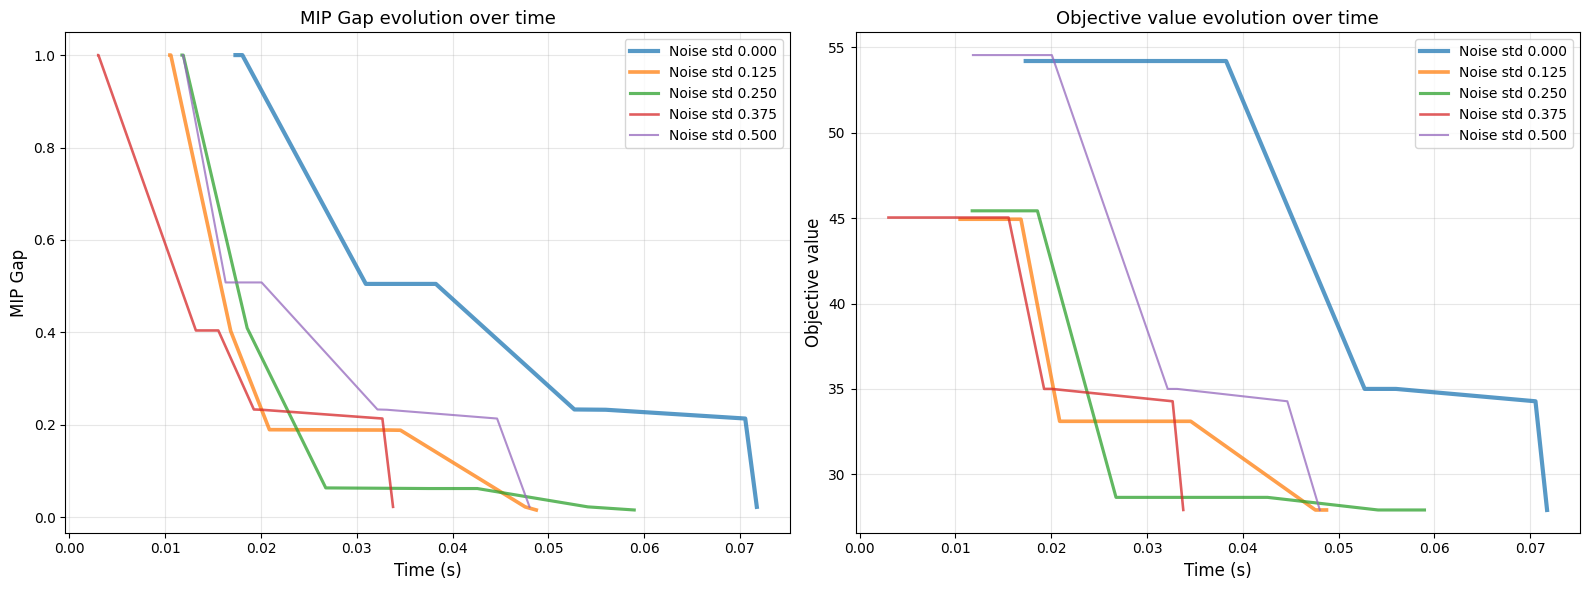

In [2]:
seed = np.random.randint(0, 1e8)
print(f"Using seed: {seed}")
base_inst = CFLInstance(10, 50, rho=0.5, seed=seed)

gaps_evolution = []
obj_evolution = []

n_repeats = 1

for std in np.linspace(0, 0.5, 5):
    best_times = [float("inf")]
    best_vals = None
    for trial in range(n_repeats):
        base_inst.seed = np.random.randint(0, 1e8)
        relaxed_inst = base_inst.get_relaxation(noise_level=std)
        
        relaxed_inst.Params.OutputFlag = 0
        relaxed_inst.Params.TimeLimit = 30
        relaxed_inst.optimize()

        warmed_inst = base_inst.copy_instance_data()
        x_vals, y_vals = utils.parse_vars(
            relaxed_inst.getVars(), base_inst.n_facilities, base_inst.n_clients
        )
        warmed_inst.init_warm_start(x_vals=x_vals, y_vals=y_vals)

        vals, times = warmed_inst.solve(timeout=30, gap=1e-9)
        print(warmed_inst.m.Runtime, warmed_inst.m.ObjVal)

        if times[-1] < best_times[-1]:
            best_times = times
            best_vals = vals

    obj_vals = [v[0] for v in best_vals]
    gap = utils.compute_gaps_from_callback(best_vals)

    gaps_evolution.append((best_times, gap, std))
    obj_evolution.append((best_times, obj_vals, std))

linewidths = np.linspace(3, 1.5, len(gaps_evolution))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (t, gap, std) in enumerate(gaps_evolution):
    axes[0].plot(
        t,
        gap,
        linewidth=linewidths[idx],
        label=f"Noise std {std:.3f}",
        alpha=0.75,
    )

axes[0].set_ylabel("MIP Gap", fontsize=12)
axes[0].set_xlabel("Time (s)", fontsize=12)
axes[0].set_title("MIP Gap evolution over time", fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for idx, (t, obj_vals, std) in enumerate(obj_evolution):
    axes[1].plot(
        t,
        obj_vals,
        linewidth=linewidths[idx],
        label=f"Noise std {std:.3f}",
        alpha=0.75,
    )

axes[1].set_ylabel("Objective value", fontsize=12)
axes[1].set_xlabel("Time (s)", fontsize=12)
axes[1].set_title("Objective value evolution over time", fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
